In [1]:
import qiskit

In [2]:
qiskit.__version__

'1.4.1'

In [3]:
from qiskit import QuantumCircuit, ClassicalRegister,QuantumRegister,transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import QFT, PhaseGate, RYGate, HGate, RZGate, UnitaryGate
import matplotlib.pyplot as plt
import numpy as np
from cmath import phase
from scipy.optimize import minimize, least_squares
from math import factorial

In [4]:
def erase_zeros(coeff, eps=1e-12):
    """Recorta solo ceros de cola. La uso fuera de la recursión."""
    coeff = np.asarray(coeff, dtype=complex)
    deg = len(coeff)-1
    while deg > 0 and abs(coeff[deg]) < eps:
        deg -= 1
    return coeff[:deg+1]

def canonical_phase(x):
    """Usa Arg en (-π, π]; no hace falta re-mapear a [0,2π)."""
    return np.angle(x)

def finding_angles(P, Q, eps=1e-12):
    P = np.asarray(P, dtype=complex)
    Q = np.asarray(Q, dtype=complex)

    # 1) Eliminar solo ceros de cola una vez, para fijar el grado
    P = erase_zeros(P, eps)
    Q = erase_zeros(Q, eps)

    degP = len(P) - 1
    degQ = len(Q) - 1
    d = max(degP, degQ)

    # Asegurarnos de que P y Q tengan longitud d+1
    P = np.pad(P, (0, d + 1 - len(P)))
    Q = np.pad(Q, (0, d + 1 - len(Q)))

    # Listas de ángulos
    theta_list = [0.0] * (d + 1)
    phi_list   = [0.0] * (d + 1)

    curP = P.copy()
    curQ = Q.copy()
    curd = d

    # 2) Recursión desde el grado d hacia 1
    while curd > 0:
        a = curP[curd]
        b = curQ[curd]

        theta_i = np.arctan2(abs(b), abs(a))
        if abs(b) < eps:
            phi_i = canonical_phase(a)
        else:
            phi_i = canonical_phase(a / b)

        theta_list[curd] = theta_i
        phi_list[curd]   = phi_i

        # Aplicar R(θ_i, φ_i, 0)^\dagger como en el paper
        c = np.cos(theta_i)
        s = np.sin(theta_i)
        e = np.exp(-1j * phi_i)

        # S' = R^\dagger S
        U_hatP = c * e * curP + s * curQ      # fila superior de S'
        hatQ   = s * e * curP - c * curQ      # fila inferior de S'

        # Shift: Ŝ[0] = S'[0][1:curd+1], Ŝ[1] = S'[1][0:curd]
        newP = np.zeros(curd, dtype=complex)
        newQ = np.zeros(curd, dtype=complex)
        newP[:] = U_hatP[1:curd+1]
        newQ[:] = hatQ[0:curd]

        curP = newP
        curQ = newQ
        curd -= 1

    # 3) Grado 0: extraer λ, θ0, φ0
    a0 = curP[0] if len(curP) > 0 else 1.0 + 0j
    b0 = curQ[0] if len(curQ) > 0 else 0.0 + 0j

    if abs(b0) < eps:
        lam  = 0.0
        phi0 = canonical_phase(a0)
    else:
        lam  = canonical_phase(b0)
        phi0 = canonical_phase(a0 / b0)

    theta0 = np.arctan2(abs(b0), abs(a0))

    theta_list[0] = theta0
    phi_list[0]   = phi0

    return lam, theta_list, phi_list


In [5]:
#Qiskit circuit
def R_gqsp(theta,phi,lam):
    c= np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [np.exp(1j*(lam+phi))*c, np.exp(1j*phi)*s],
        [np.exp(1j*lam)*s,      -c]
    ], dtype= complex)
def apply_U_control(qc,anc,datos,U):
    Uc= U.control(1)
    qc.x(anc)
    qc.append(Uc, [anc,datos])
    qc.x(anc)
    
def build_GQSPcircuit(lam,theta,phi,U):
    qd= QuantumRegister(1,"dat")
    qa= QuantumRegister(1,"anc")
    qc= QuantumCircuit(qd,qa)

    qc.unitary(R_gqsp(theta[0],phi[0],lam), [qa[0]])

    for i in range(1, len(theta)):
        apply_U_control(qc,qa[0],qd[0],U)
        qc.unitary(R_gqsp(theta[i],phi[i],0.0), [qa[0]])
           
    return qc

In [6]:
#Example 1 - having P and Q
P=np.array([0,3/4,1/4], dtype=complex)
Q=(np.sqrt(3)/4) * np.array([0,1,-1], dtype=complex)
lam, list_theta, list_phi=finding_angles(P,Q)
print("lambda:", lam)
print("thetas:", list_theta)
print("phis:", list_phi)

lambda: 0.0
thetas: [np.float64(1.4960555235404307e-16), np.float64(1.0471975511965979), np.float64(1.0471975511965976)]
phis: [np.float64(3.141592653589793), np.float64(6.123233995736765e-17), np.float64(-3.141592653589793)]


In [7]:
U= HGate()
qc= build_GQSPcircuit(lam,list_theta,list_phi,U)
print(qc)

                     ┌───┐                     ┌───┐                
dat: ────────────────┤ H ├─────────────────────┤ H ├────────────────
     ┌─────────┐┌───┐└─┬─┘┌───┐┌─────────┐┌───┐└─┬─┘┌───┐┌─────────┐
anc: ┤ Unitary ├┤ X ├──■──┤ X ├┤ Unitary ├┤ X ├──■──┤ X ├┤ Unitary ├
     └─────────┘└───┘     └───┘└─────────┘└───┘     └───┘└─────────┘


In [8]:
#f(x)-fGQSP(x)=0?
U_total = Operator(qc).data
F_GQSP = U_total[0:2, 0:2]
U_single= Operator(U).data
P_U = 0.25 *(U_single@U_single + 3*U_single)
print("||P_U - F_GQSP|| =", np.linalg.norm(P_U-F_GQSP))

||P_U - F_GQSP|| = 2.7839876563586136e-16


In [9]:
# Convolución lineal mediante FFT
def conv_fft(x, y):
   
    x = np.asarray(x, dtype=complex)
    y = np.asarray(y, dtype=complex)
    n = len(x) + len(y) - 1

    nfft = 1
    while nfft < n:
        nfft <<= 1

    X = np.fft.fft(x, nfft)
    Y = np.fft.fft(y, nfft)
    return np.fft.ifft(X * Y)[:n]

# Residuos de la ecuación (41) para grado 2
# -----------------------------------------
def residual_eq41_quadratic(b_flat, a):
    """
    a: coeficientes de P (complex, len=3)
    b_flat: [Re(b0),Re(b1),Re(b2), Im(b0),Im(b1),Im(b2)]

    Devuelve residuo real+imag como vector real de longitud 10:
    [Re(resid_0..4), Im(resid_0..4)]
    donde
      resid = a * rev(a)^* + b * rev(b)^* - delta
    """
    a = np.asarray(a, dtype=complex)
    L = len(a)
    assert L == 3 

    # reconstruir b complejo
    b_real = b_flat[:L]
    b_imag = b_flat[L:]
    b = b_real + 1j * b_imag

    # reverse(a)^* y reverse(b)^*
    rev_a_star = np.conj(a[::-1])
    rev_b_star = np.conj(b[::-1])

    # convoluciones
    conv_a = conv_fft(a, rev_a_star)   # len = 2L-1 = 5
    conv_b = conv_fft(b, rev_b_star)

    # delta con 1 en el centro
    delta = np.zeros(2*L - 1, dtype=complex)
    delta[L - 1] = 1.0

    resid = conv_a + conv_b - delta  # vector complejo de len=5

    # devolvemos real e imaginario concatenados (para least_squares)
    return np.concatenate([resid.real, resid.imag])


# Hallar Q para P de grado 2 (usando eq. 41)
def find_Q_quadratic(P, n_starts=5, verbose=False):
    """
    Dado P (len=3, grado 2) halla Q (len=3) tal que
       |P(e^{iθ})|^2 + |Q(e^{iθ})|^2 ≈ 1
    usando la ecuación (41) del paper:
       a * rev(a)^* + b * rev(b)^* = delta
    """
    a = np.asarray(P, dtype=complex)
    L = len(a)
    assert L == 3, "P debe ser un polinomio de grado 2 (len(P) == 3)."

    best_res_norm = np.inf
    best_Q = None

    for s in range(n_starts):
        # inicialización aleatoria pequeña
        init = 0.01 * np.random.randn(2 * L)

        sol = least_squares(
            residual_eq41_quadratic,
            init,
            args=(a,),
            ftol=1e-15,
            xtol=1e-15,
            gtol=1e-15,
            max_nfev=50000
        )

        b_flat = sol.x
        b_real = b_flat[:L]
        b_imag = b_flat[L:]
        Q = b_real + 1j * b_imag

        res_vec = residual_eq41_quadratic(b_flat, a)
        res_norm = np.linalg.norm(res_vec)

        if verbose:
            print(f"[start {s}] ||resid(eq41)||_2 = {res_norm}")

        if res_norm < best_res_norm:
            best_res_norm = res_norm
            best_Q = Q

    if verbose:
        print("Mejor norma de residuo (eq.41) =", best_res_norm)
        print("Q_best =", best_Q)

    return best_Q, best_res_norm

# |P|^2 + |Q|^2 

def check_circle(P, Q, num_points=500):
    xs = np.linspace(0, 2*np.pi, num_points)
    vals = []
    for x in xs:
        z = np.exp(1j*x)
        Pz = np.polyval(P[::-1], z)
        Qz = np.polyval(Q[::-1], z)
        vals.append(abs(Pz)**2 + abs(Qz)**2)
    vals = np.array(vals)
    print("min |P|^2+|Q|^2:", vals.min(), "max:", vals.max())
    return vals.min(), vals.max()

In [10]:
#Example 2 - Having P and finding Q
Q_2, res_norm = find_Q_quadratic(P, n_starts=10, verbose=True)
print("Q_num =", Q_2)
print("||resid(eq41)||_2 =", res_norm)

# Comprobar en el círculo unitario
check_circle(P, Q_2, num_points=1000)

[start 0] ||resid(eq41)||_2 = 4.145900892737289e-15
[start 1] ||resid(eq41)||_2 = 2.5270881624365087e-15
[start 2] ||resid(eq41)||_2 = 1.2490976451784955e-15
[start 3] ||resid(eq41)||_2 = 8.28086563530091e-16
[start 4] ||resid(eq41)||_2 = 5.904459024058845e-16
[start 5] ||resid(eq41)||_2 = 8.3365878311806e-17
[start 6] ||resid(eq41)||_2 = 4.8074067159589095e-17
[start 7] ||resid(eq41)||_2 = 1.1422240595049123e-16
[start 8] ||resid(eq41)||_2 = 1.4015878649856313e-16
[start 9] ||resid(eq41)||_2 = 6.46447023504804e-16
Mejor norma de residuo (eq.41) = 4.8074067159589095e-17
Q_best = [ 3.83771326e-01+2.00548163e-01j -3.83771334e-01-2.00548167e-01j
 -1.10239754e-17+1.45325303e-17j]
Q_num = [ 3.83771326e-01+2.00548163e-01j -3.83771334e-01-2.00548167e-01j
 -1.10239754e-17+1.45325303e-17j]
||resid(eq41)||_2 = 4.8074067159589095e-17
min |P|^2+|Q|^2: 0.9999999999999997 max: 1.0000000000000007


(np.float64(0.9999999999999997), np.float64(1.0000000000000007))

In [11]:
Q_true = np.array([0.0, 0.4330127, -0.4330127], dtype=complex)
print("||Q_num - Q_true|| =", np.linalg.norm(Q_2 - Q_true))

||Q_num - Q_true|| = 1.040363263236434


In [12]:
lam, list_theta, list_phi=finding_angles(P,Q_2)
print("lambda:", lam)
print("thetas:", list_theta)
print("phis:", list_phi)

lambda: 0.4815417462473297
thetas: [np.float64(1.0471975469495975), np.float64(1.047197555443598), np.float64(0.0)]
phis: [np.float64(0.0), np.float64(-0.4815417462473297), np.float64(0.0)]


In [13]:
U= RYGate(np.pi/3)
qc= build_GQSPcircuit(lam,list_theta,list_phi,U)
print(qc)

                     ┌─────────┐                     ┌─────────┐     »
dat: ────────────────┤ Ry(π/3) ├─────────────────────┤ Ry(π/3) ├─────»
     ┌─────────┐┌───┐└────┬────┘┌───┐┌─────────┐┌───┐└────┬────┘┌───┐»
anc: ┤ Unitary ├┤ X ├─────■─────┤ X ├┤ Unitary ├┤ X ├─────■─────┤ X ├»
     └─────────┘└───┘           └───┘└─────────┘└───┘           └───┘»
«                
«dat: ───────────
«     ┌─────────┐
«anc: ┤ Unitary ├
«     └─────────┘


In [14]:
#f(x)-fGQSP(x)=0?
U_total = Operator(qc).data
F_GQSP = U_total[0:2, 0:2]
U_single= Operator(U).data
P_U = 0.25 *(U_single@U_single + 3*U_single)
print("||P_U - F_GQSP|| =", np.linalg.norm(P_U-F_GQSP))


||P_U - F_GQSP|| = 3.5988718893570193e-16


In [15]:
def taylor_P(t, L, n_samples=4096):
    
    # 1) Taylor original
    P = np.zeros(L+1, dtype=complex)
    for k in range(L+1):
        P[k] = ((-1j * t)**k) / factorial(k)

    # 2) Evaluar en el círculo unitario
    thetas = np.linspace(0, 2*np.pi, n_samples, endpoint=False)
    z = np.exp(1j * thetas)

    vals = np.zeros_like(z, dtype=complex)
    z_powers = np.ones_like(z, dtype=complex)  # z^0
    for ak in P:
        vals += ak * z_powers
        z_powers *= z  # siguiente potencia

    max_mod = np.max(np.abs(vals))

    # 3) Normalizar si hace falta
    if max_mod > 1.0:
        P_norm = P / max_mod
    else:
        P_norm = P.copy()

    return P_norm, max_mod

def conv_fft(x, y):
    
    x = np.asarray(x, dtype=complex)
    y = np.asarray(y, dtype=complex)
    n = len(x) + len(y) - 1

    nfft = 1
    while nfft < n:
        nfft <<= 1

    X = np.fft.fft(x, nfft)
    Y = np.fft.fft(y, nfft)
    return np.fft.ifft(X * Y)[:n]

def residual_eq41_general(b_flat, a):

    a = np.asarray(a, dtype=complex)
    L = len(a)

    b_real = b_flat[:L]
    b_imag = b_flat[L:]
    b = b_real + 1j * b_imag

    rev_a_star = np.conj(a[::-1])
    rev_b_star = np.conj(b[::-1])

    conv_a = conv_fft(a, rev_a_star)     # len = 2L-1
    conv_b = conv_fft(b, rev_b_star)

    delta = np.zeros(2*L - 1, dtype=complex)
    delta[L - 1] = 1.0

    resid = conv_a + conv_b - delta      # complejo, len=2L-1

    return np.concatenate([resid.real, resid.imag])

def fejer_riesz_initial_Q(P, n_samples_factor=8):
    a = np.asarray(P, dtype=complex)
    L = len(a)

    # número de muestras en el círculo (potencia de 2, suficientemente grande)
    N = 1
    while N < n_samples_factor * L:
        N <<= 1

    thetas = 2*np.pi * np.arange(N) / N
    z = np.exp(1j * thetas)

    # evaluar P(z_j)
    P_vals = np.zeros(N, dtype=complex)
    z_powers = np.ones(N, dtype=complex)  # z^0
    for ak in a:
        P_vals += ak * z_powers
        z_powers *= z

    # f(θ) = 1 - |P|^2 (clip para evitar negativos por redondeo)
    f_theta = 1.0 - np.abs(P_vals)**2
    f_theta = np.maximum(f_theta, 0.0)

    # Fejér–Riesz: Q(e^{iθ}) = sqrt(f(θ)), eligiendo fase real no negativa
    Q_vals = np.sqrt(f_theta).astype(complex)

    # Coeficientes de Q mediante IFFT
    coeffs = np.fft.ifft(Q_vals)  # (1/N) sum_j Q_vals_j e^{-ikθ_j}
    Q_init = coeffs[:L]          # nos quedamos con grados 0..L-1

    return Q_init

def fejer_riesz_Q_from_P(P, n_starts=3, n_samples_factor=8, verbose=False):
    a = np.asarray(P, dtype=complex)
    L = len(a)

    # Paso 1: Q inicial por Fejér–Riesz numérico
    Q_init = fejer_riesz_initial_Q(a, n_samples_factor=n_samples_factor)

    best_Q = None
    best_res_norm = np.inf

    base_scale = np.max(np.abs(Q_init))
    if base_scale == 0:
        base_scale = 1.0
    #noise_level = 1e-3 * base_scale
    noise_level = 0.0


    for s in range(n_starts):
        # pequeña perturbación aleatoria alrededor de Q_init
        noise = noise_level * (np.random.randn(L) + 1j*np.random.randn(L))
        Q0 = Q_init + noise

        b0 = np.concatenate([Q0.real, Q0.imag])

        sol = least_squares(
            residual_eq41_general,
            b0,
            args=(a,),
            ftol=1e-15,
            xtol=1e-15,
            gtol=1e-15,
            max_nfev=50000
        )

        b_opt = sol.x
        b_real = b_opt[:L]
        b_imag = b_opt[L:]
        Q = b_real + 1j*b_imag

        res_vec = residual_eq41_general(b_opt, a)
        res_norm = np.linalg.norm(res_vec)

        if verbose:
            print(f"[start {s}] ||resid(eq41)||_2 = {res_norm}")

        if res_norm < best_res_norm:
            best_res_norm = res_norm
            best_Q = Q

    if verbose:
        print("Mejor norma de residuo (eq.41) =", best_res_norm)
        print("Q_best =", best_Q)

    return best_Q, best_res_norm

def check_circle(P, Q, num_points=1000):
    xs = np.linspace(0, 2*np.pi, num_points)
    vals = []
    for x in xs:
        z = np.exp(1j*x)
        Pz = np.polyval(P[::-1], z)
        Qz = np.polyval(Q[::-1], z)
        vals.append(abs(Pz)**2 + abs(Qz)**2)
    vals = np.array(vals)
    print("min |P|^2+|Q|^2:", vals.min(), "max:", vals.max())
    return vals.min(), vals.max()
def poly_of_U(P, U):
    """
    P(U) = sum_{k=0}^L P[k] U^k
    P[0] = a0, P[1] = a1, ...
    """
    P = np.asarray(P, dtype=complex)
    n = U.shape[0]
    res = np.zeros((n, n), dtype=complex)
    power = np.eye(n, dtype=complex)  # U^0
    for ak in P:
        res += ak * power
        power = power @ U
    return res

In [16]:
#example 3 - Taylor series and finding Q
t = 5
L = 20

P_3, scale = taylor_P(t, L)
Q_3, res_norm = fejer_riesz_Q_from_P(P_3, n_samples_factor=32, n_starts=6)
print("||resid(eq41)||_2 =", res_norm)

check_circle(P_3, Q_3, num_points=2000)

||resid(eq41)||_2 = 2.582196240889831e-15
min |P|^2+|Q|^2: 0.9999999999999987 max: 1.0000000000000082


(np.float64(0.9999999999999987), np.float64(1.0000000000000082))

In [17]:
from scipy.linalg import expm

# Pauli-Y Hermitiana
Y = np.array([
    [0, -1j],
    [1j,  0]
], dtype=complex)

theta = np.pi/3     # ángulo de la puerta RY
t = 1.0             # tiempo de evolución

# Hamiltoniano correcto: H = (pi/6) Y
H = (theta/2) * Y   # = (pi/6) * Y

# Evolución física exacta
U_exact = expm(-1j * H * t)

print("U_exact = exp(-i H t):")
print(U_exact)

# Unitaria base usada en QSP (RY(pi/3))
U_base = Operator(RYGate(theta)).data

U_exact = exp(-i H t):
[[ 0.8660254+0.j -0.5      +0.j]
 [ 0.5      +0.j  0.8660254+0.j]]


In [18]:
ts = np.linspace(1, 20, 20)  # t = 1, 1.5, 2, ..., 10
L = 20

results = []
for t in ts:
    P_t, scale = taylor_P(t, L)
    Q_t, res_norm = fejer_riesz_Q_from_P(P_t, n_samples_factor=32, n_starts=6)
    norm2 = np.sum(np.abs(P_t)**2) + np.sum(np.abs(Q_t)**2)
    P_t /= np.sqrt(norm2)
    Q_t /= np.sqrt(norm2)
    lam_t, th_t, ph_t = finding_angles(P_t, Q_t)

    U = RYGate(np.pi/3)
    qc = build_GQSPcircuit(lam_t, th_t, ph_t, U)

    U_total = Operator(qc).data
    F_GQSP = U_total[0:2, 0:2]
    U_single = Operator(U).data
    P_U = poly_of_U(P_t, U_base)

    phase_shift = np.angle(np.vdot(P_U.flatten(), F_GQSP.flatten()))
    F_aligned = np.exp(-1j * phase_shift) * F_GQSP

    err = np.linalg.norm(P_U - F_aligned)
    
    print(f"\n================ t = {t:.2f} ================")
    print(f"err = {err:.3e}, resid_eq41 = {res_norm:.3e}")
    print("U_total")
    print(U_total)
    print("P_U =")
    print(P_U)
    print("F_aligned =")
    print(F_aligned)

    results.append((t, err, res_norm))


================ t = 1.00 ================
err = 8.950e-01, resid_eq41 = 7.886e-16
U_total
[[-0.10097384+0.43820966j  0.14210303-0.65103201j -0.17988708+0.00286674j
  -0.56619131+0.0282922j ]
 [-0.14210303+0.65103201j -0.10097384+0.43820966j  0.56619131-0.0282922j
  -0.17988708+0.00286674j]
 [-0.40044924-0.02206188j -0.43892285-0.01552553j -0.17551917-0.78247637j
   0.01653004+0.05394331j]
 [ 0.43892285+0.01552553j -0.40044924-0.02206188j -0.01653004-0.05394331j
  -0.17551917-0.78247637j]]
P_U =
[[ 0.26875176-0.31600121j  0.14602958+0.1241948j ]
 [-0.14602958-0.1241948j   0.26875176-0.31600121j]]
F_aligned =
[[ 0.04849161-0.44707045j -0.06418752+0.66326157j]
 [ 0.06418752-0.66326157j  0.04849161-0.44707045j]]

================ t = 2.00 ================
err = 4.549e-01, resid_eq41 = 6.668e-16
U_total
[[-0.52158241-0.0712007j   0.06861519-0.18445949j  0.21782822+0.76292153j
   0.17633405+0.15348228j]
 [-0.06861519+0.18445949j -0.52158241-0.0712007j  -0.17633405-0.15348228j
   0.21782822

In [19]:
lam_T, th_T, ph_T= finding_angles(P_3, Q_3)

print("lam:", lam_T)
print("thetas:", th_T)
print("phis:", ph_T)

lam: 1.9091157183441726e-08
thetas: [np.float64(1.5707960149597722), np.float64(0.012341882693736525), np.float64(0.0040452649844775765), np.float64(0.0006318807511777222), np.float64(0.00012412590651411385), np.float64(0.00012037501893269382), np.float64(0.0005926243740740241), np.float64(0.0018222248606908718), np.float64(0.004852087484309795), np.float64(0.011892578872546272), np.float64(0.026844418636104553), np.float64(0.055412153933938744), np.float64(0.10349527701030904), np.float64(0.17185855086280644), np.float64(0.24652187671203693), np.float64(0.2939807399352493), np.float64(0.280701905366533), np.float64(0.2078548310869816), np.float64(0.11433524087309997), np.float64(0.04231059324604718), np.float64(0.007953658987618671)]
phis: [np.float64(-0.9762536594295846), np.float64(1.560670316980476), np.float64(1.5324930459396906), np.float64(-1.1719429275313433), np.float64(2.8893261646407797), np.float64(2.387513410143457), np.float64(1.627801457783174), np.float64(1.575193228624

In [20]:
U= RYGate(np.pi/3)
qc= build_GQSPcircuit(lam_T,th_T,ph_T,U)
print(qc)

                     ┌─────────┐                     ┌─────────┐     »
dat: ────────────────┤ Ry(π/3) ├─────────────────────┤ Ry(π/3) ├─────»
     ┌─────────┐┌───┐└────┬────┘┌───┐┌─────────┐┌───┐└────┬────┘┌───┐»
anc: ┤ Unitary ├┤ X ├─────■─────┤ X ├┤ Unitary ├┤ X ├─────■─────┤ X ├»
     └─────────┘└───┘           └───┘└─────────┘└───┘           └───┘»
«                     ┌─────────┐                     ┌─────────┐     »
«dat: ────────────────┤ Ry(π/3) ├─────────────────────┤ Ry(π/3) ├─────»
«     ┌─────────┐┌───┐└────┬────┘┌───┐┌─────────┐┌───┐└────┬────┘┌───┐»
«anc: ┤ Unitary ├┤ X ├─────■─────┤ X ├┤ Unitary ├┤ X ├─────■─────┤ X ├»
«     └─────────┘└───┘           └───┘└─────────┘└───┘           └───┘»
«                     ┌─────────┐                     ┌─────────┐     »
«dat: ────────────────┤ Ry(π/3) ├─────────────────────┤ Ry(π/3) ├─────»
«     ┌─────────┐┌───┐└────┬────┘┌───┐┌─────────┐┌───┐└────┬────┘┌───┐»
«anc: ┤ Unitary ├┤ X ├─────■─────┤ X ├┤ Unitary ├┤ X ├─────■─────┤ X 

In [21]:
#f(x)-fGQSP(x)=0?
U_total = Operator(qc).data
F_GQSP = U_total[0:2, 0:2]
U_single= Operator(U).data
P_U = poly_of_U(P_3, U_base)
#no global phase
phase = np.angle(np.vdot(P_U.flatten(), F_GQSP.flatten()))
F_aligned = np.exp(-1j * phase) * F_GQSP
err = np.linalg.norm(P_U - F_aligned)
print("||P_U - F_GQSP|| =", err)

||P_U - F_GQSP|| = 0.01643765897939939


In [22]:
#graphs
def plot_unitarity_curve(P, Q, label=None, num_points=400):

    P = np.asarray(P, dtype=complex)
    Q = np.asarray(Q, dtype=complex)

    thetas = np.linspace(0, 2*np.pi, num_points, endpoint=False)
    z = np.exp(1j * thetas)

    vals = []
    for x in z:
        Pz = np.polyval(P[::-1], x)
        Qz = np.polyval(Q[::-1], x)
        vals.append(np.abs(Pz)**2 + np.abs(Qz)**2)
    vals = np.array(vals)

    plt.figure()
    plt.plot(thetas, vals, label=label)
    plt.axhline(1.0, color='k', linestyle='--', linewidth=1)  # línea ideal = 1
    plt.xlabel(r'$\theta$')
    plt.ylabel(r'$|P(e^{i\theta})|^2 + |Q(e^{i\theta})|^2$')
    if label is not None:
        plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("min |P|^2+|Q|^2:", vals.min(), "max:", vals.max())

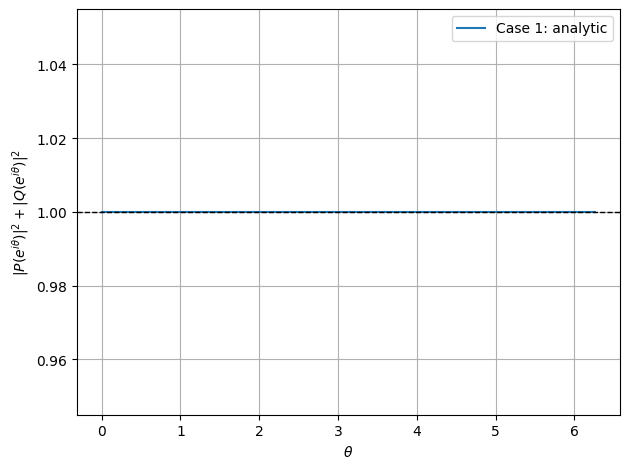

min |P|^2+|Q|^2: 0.9999999999999996 max: 1.0000000000000004


In [23]:
P1 = np.array([0, 3/4, 1/4], dtype=complex)
Q1 = (np.sqrt(3)/4) * np.array([0, 1, -1], dtype=complex)
plot_unitarity_curve(P1, Q1, label="Case 1: analytic")

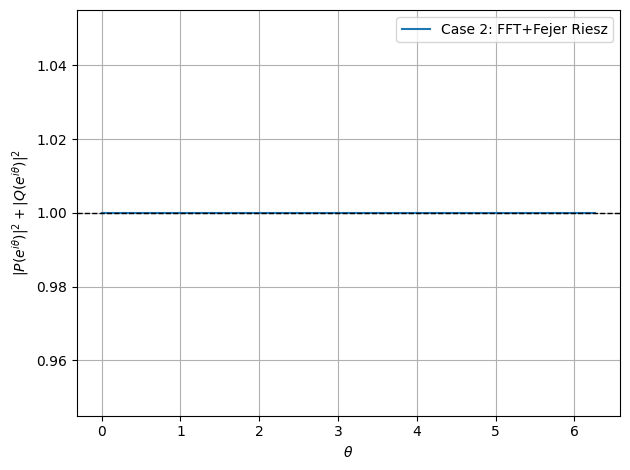

min |P|^2+|Q|^2: 0.9999999999999997 max: 1.0000000000000007


In [24]:
P2 = P1
Q2 = Q_2   
plot_unitarity_curve(P2, Q2, label="Case 2: FFT+Fejer Riesz")

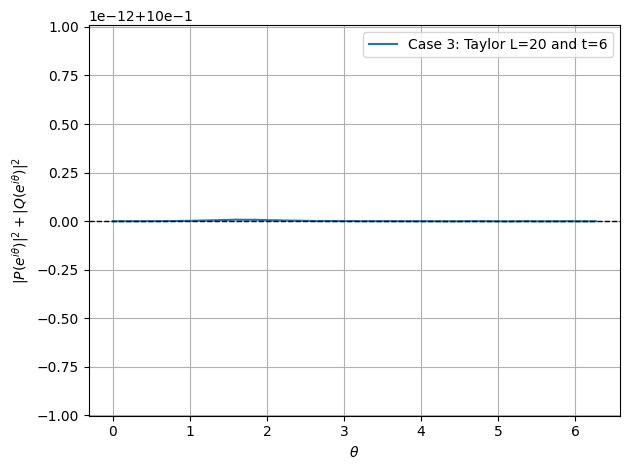

min |P|^2+|Q|^2: 0.9999999999999989 max: 1.0000000000000082


In [25]:
P3 = P_3
Q3 = Q_3  
plot_unitarity_curve(P3, Q3, label=f"Case 3: Taylor L={L} and t=6")